In [6]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("joebeachcapital/realwaste")
print("Path to dataset files:", path)

data_subpath = os.path.join(path, 'realwaste-main')
realwaste_dir = os.path.join(data_subpath, 'RealWaste')

image_data = []

if os.path.exists(realwaste_dir):
    for category_name in os.listdir(realwaste_dir):
        category_path = os.path.join(realwaste_dir, category_name)

        if os.path.isdir(category_path):
            for filename in os.listdir(category_path):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
                    filepath = os.path.join(category_path, filename)
                    image_data.append({
                        'filepath': filepath,
                        'label': category_name
                    })
else:
    print(f"Error: Directory not found at {realwaste_dir}")

df_images = pd.DataFrame(image_data)

print(f"DataFrame recreated with {len(df_images)} entries.")
print(df_images.head())

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\joebeachcapital\realwaste\versions\1
DataFrame recreated with 4752 entries.
                                            filepath      label
0  C:\Users\user\.cache\kagglehub\datasets\joebea...  Cardboard
1  C:\Users\user\.cache\kagglehub\datasets\joebea...  Cardboard
2  C:\Users\user\.cache\kagglehub\datasets\joebea...  Cardboard
3  C:\Users\user\.cache\kagglehub\datasets\joebea...  Cardboard
4  C:\Users\user\.cache\kagglehub\datasets\joebea...  Cardboard


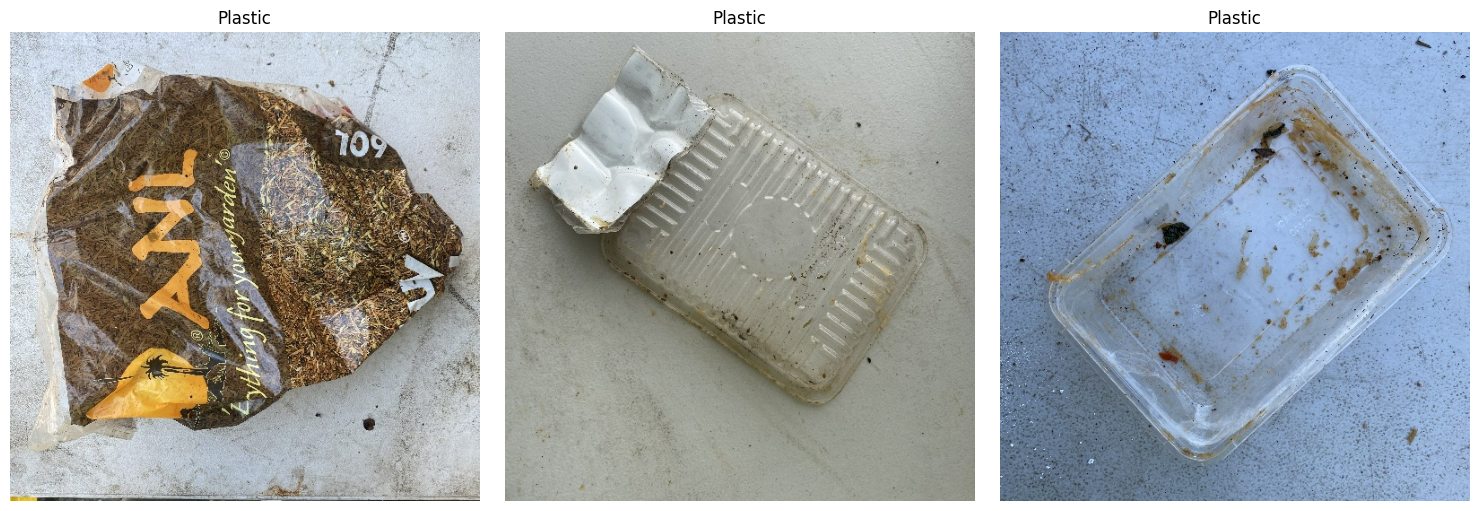

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Filter for 'Textile Trash' images
textile_images_df = df_images[df_images['label'] == 'Plastic']

if not textile_images_df.empty:
    # Select 3 random images
    sample_images = textile_images_df.sample(n=3, random_state=42)

    plt.figure(figsize=(15, 5))
    for i, row in enumerate(sample_images.iterrows()):
        filepath = row[1]['filepath']
        label = row[1]['label']

        img = mpimg.imread(filepath)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No images found for the category 'Textile Trash'.")
    print("Available categories are:", df_images['label'].unique())

In [ ]:
import tensorflow as tf
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

# Shuffle the dataframe — flow_from_dataframe's validation_split takes the LAST 20%
# by index, so a class-sorted df_images produces a val set missing most classes.
df_images = df_images.sample(frac=1, random_state=SEED).reset_index(drop=True)

# EfficientNetV2 expects raw [0, 255] input — preprocess_input is essentially a no-op
# but we use it explicitly so swapping backbones later stays safe.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='reflect',
    validation_split=0.2,
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
)

print("Setting up data generators...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_images,
    x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED,
)
val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_images,
    x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED,
)

NUM_CLASSES = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print(f"Classes ({NUM_CLASSES}):", class_names)

# Handle class imbalance
y_train = train_generator.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weights)

# Build model — EfficientNetV2B0 is a stronger backbone than MobileNetV2 at similar cost
base_model = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')],
)
model.summary()

CKPT_PATH = 'best_trash_model.keras'
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
]

print("\nPhase 1: Training classifier head (frozen backbone)...")
history_head = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


Setting up data generators...
Found 3802 validated image filenames belonging to 9 classes.
Found 950 validated image filenames belonging to 9 classes.
Classes (9): ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class weights: {0: 1.1833177715530656, 1: 1.3078775369797042, 2: 1.2572751322751323, 3: 0.6600694444444445, 4: 1.0587580061264272, 5: 1.0587580061264272, 6: 0.5685658740840437, 7: 1.6373815676141257, 8: 1.217419148254883}


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,255,705 (23.86 MB)

 Trainable params: 333,321 (1.27 MB)

 Non-trainable params: 5,922,384 (22.59 MB)


Phase 1: Training classifier head (frozen backbone)...
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.4340 - loss: 2.1745 - top3_acc: 0.7154
Epoch 1: val_accuracy improved from None to 0.76105, saving model to best_trash_model.keras

Epoch 1: finished saving model to best_trash_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 120s 910ms/step - accuracy: 0.5413 - loss: 1.7909 - top3_acc: 0.8104 - val_accuracy: 0.7611 - val_loss: 1.0645 - val_top3_acc: 0.9495 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.6678 - loss: 1.3510 - top3_acc: 0.8979
Epoch 2: val_accuracy improved from 0.76105 to 0.80947, saving model to best_trash_model.keras

Epoch 2: finished saving model to best_trash_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 109s 912ms/step - accuracy: 0.6718 - loss: 1.3041 - top3_acc: 0.9087 - val_accuracy: 0.8095 - val_loss: 0.9576 - val_top3_acc: 0.9663 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step

In [9]:
# Phase 2: Fine-tune the top portion of the backbone with a low learning rate.
# Unfreezing only the last ~30% gives a big accuracy bump without overfitting on a small dataset.
print("Phase 2: Fine-tuning top layers of backbone...")
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
# Keep BatchNorm layers in inference mode to avoid destabilizing pretrained stats
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(
    [tf.keras.backend.count_params(w) for w in model.trainable_weights]
)
print(f"Trainable params after unfreeze: {trainable_count:,}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')],
)

history_finetune = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


Phase 2: Fine-tuning top layers of backbone...
Trainable params after unfreeze: 3,401,721
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.8254 - loss: 0.8870 - top3_acc: 0.9772
Epoch 1: val_accuracy improved from 0.86632 to 0.86947, saving model to best_trash_model.keras

Epoch 1: finished saving model to best_trash_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8219 - loss: 0.9026 - top3_acc: 0.9750 - val_accuracy: 0.8695 - val_loss: 0.8477 - val_top3_acc: 0.9747 - learning_rate: 1.0000e-05
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.8377 - loss: 0.8963 - top3_acc: 0.9739
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy improved from 0.86947 to 0.87263, saving model to best_trash_model.keras

Epoch 2: finished saving model to best_trash_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.8343 - loss: 0.8945 - top3_acc: 0.9753 - val_accuracy: 0.8726 - val_l

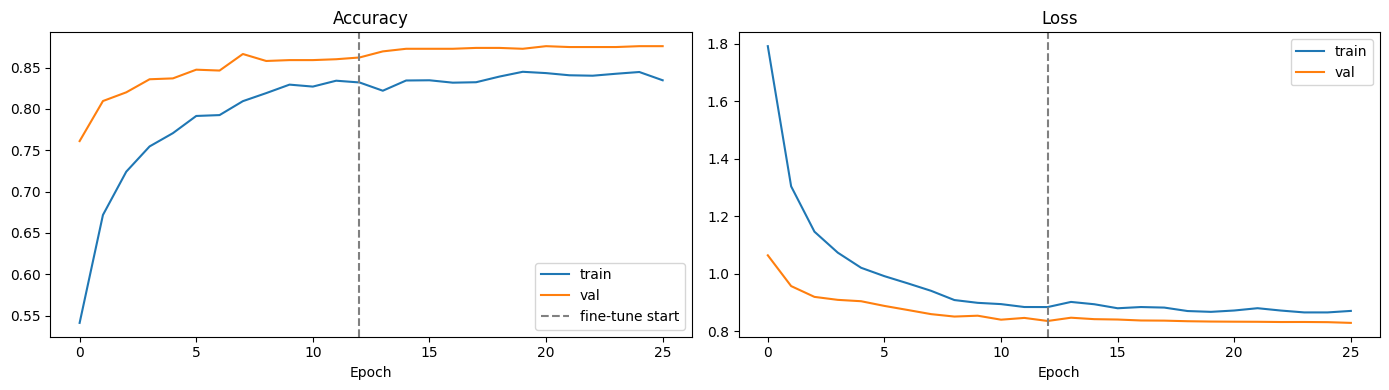


Evaluating best model on validation set...
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 479ms/step - accuracy: 0.8758 - loss: 0.8339 - top3_acc: 0.9758
Val loss: 0.8339 | Val accuracy: 0.8758 | Top-3 accuracy: 0.9758
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 568ms/step

Classification report:
                     precision    recall  f1-score   support

          Cardboard      0.773     0.952     0.853       104
      Food Organics      0.913     0.955     0.933        88
              Glass      0.833     0.893     0.862        84
              Metal      0.885     0.927     0.906       150
Miscellaneous Trash      0.849     0.760     0.802        96
              Paper      0.891     0.812     0.850       101
            Plastic      0.899     0.798     0.845       178
      Textile Trash      0.912     0.867     0.889        60
         Vegetation      0.956     0.966     0.961        89

           accuracy                          0.876       950
          macro avg      0.879     0.881     0.878       

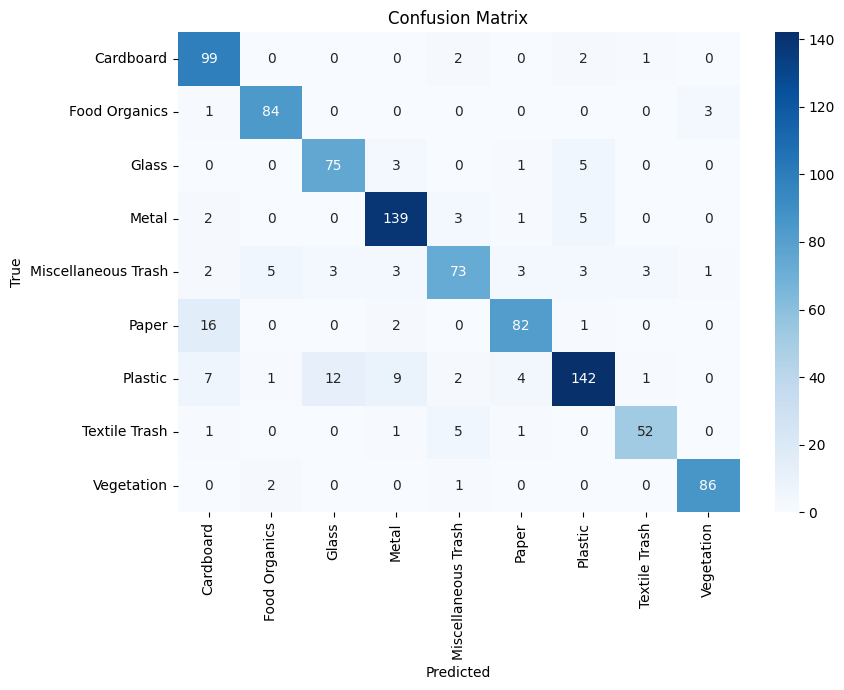

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Combine training history from both phases
def merge_hist(*histories):
    out = {}
    for h in histories:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out

hist = merge_hist(history_head, history_finetune)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist['accuracy'], label='train')
axes[0].plot(hist['val_accuracy'], label='val')
axes[0].axvline(len(history_head.history['accuracy']) - 1, color='gray', ls='--', label='fine-tune start')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist['loss'], label='train')
axes[1].plot(hist['val_loss'], label='val')
axes[1].axvline(len(history_head.history['loss']) - 1, color='gray', ls='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

# Final evaluation on the validation set
print("\nEvaluating best model on validation set...")
val_generator.reset()
loss, acc, top3 = model.evaluate(val_generator, verbose=1)
print(f"Val loss: {loss:.4f} | Val accuracy: {acc:.4f} | Top-3 accuracy: {top3:.4f}")

val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes[: len(y_pred)]

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()


In [ ]:
# --- Upload an image and classify it with the trained model ---
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

MODEL_PATH = 'best_trash_model.keras'
try:
    clf_model
except NameError:
    clf_model = load_model(MODEL_PATH)

try:
    class_names
except NameError:
    class_names = sorted(df_images['label'].unique().tolist())

IMG_SIZE = 224
TOP_K = 3


def predict_image(img: Image.Image):
    """Run the model on a PIL image and return a figure with top-k predictions."""
    img_rgb = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = preprocess_input(np.array(img_rgb, dtype=np.float32))
    probs = clf_model.predict(arr[None, ...], verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img_rgb); axes[0].axis('off')
    axes[0].set_title(f"Prediction: {class_names[top_idx[0]]} "
                      f"({probs[top_idx[0]] * 100:.1f}%)")
    labels = [class_names[i] for i in top_idx][::-1]
    values = [probs[i] * 100 for i in top_idx][::-1]
    axes[1].barh(labels, values, color='steelblue')
    axes[1].set_xlim(0, 100); axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Top-{TOP_K} predictions')
    for i, v in enumerate(values):
        axes[1].text(v + 1, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
    return fig


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    uploader = widgets.FileUpload(
        accept='image/*', multiple=False, description='Upload image',
    )
    out = widgets.Output()

    def _on_upload(change):
        if not uploader.value:
            return
        item = uploader.value[0] if isinstance(uploader.value, tuple) else next(iter(uploader.value.values()))
        content = item['content']
        with out:
            clear_output(wait=True)
            fig = predict_image(Image.open(io.BytesIO(content)))
            display(fig)
            plt.close(fig)
        # Reset uploader value so re-uploading the SAME file still fires the event
        uploader.value = () if isinstance(uploader.value, tuple) else {}

    uploader.observe(_on_upload, names='value')
    print("Click 'Upload image' below, pick a file, and the prediction will appear.")
    display(uploader, out)

except Exception as e:
    print(f"ipywidgets not usable ({e}); falling back to a Tk file dialog.")
    import tkinter as tk
    from tkinter import filedialog
    root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
    path = filedialog.askopenfilename(
        title='Select an image',
        filetypes=[('Images', '*.jpg *.jpeg *.png *.bmp *.gif *.webp')],
    )
    root.destroy()
    if path:
        fig = predict_image(Image.open(path))
        plt.show(); plt.close(fig)
    else:
        print("No file selected.")


SyntaxError: '(' was never closed (433403219.py, line 83)

In [ ]:
# --- Detect & classify individual trash items in a pile ---
# Pipeline: YOLOv8 (COCO) proposes object regions -> each crop is classified by
# our trained EfficientNetV2 trash classifier -> labeled boxes are drawn.
import sys, subprocess, importlib

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])

_ensure('ultralytics')

import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

try:
    clf_model
except NameError:
    clf_model = load_model('best_trash_model.keras')

try:
    detector
except NameError:
    print("Loading YOLOv8n (downloads ~6MB on first run)...")
    detector = YOLO('yolov8n.pt')

try:
    class_names
except NameError:
    class_names = sorted(df_images['label'].unique().tolist())

IMG_SIZE = 224
_cmap = plt.get_cmap('tab10')
_class_colors = {name: _cmap(i % 10) for i, name in enumerate(class_names)}


def detect_and_classify(img: Image.Image, det_conf=0.10, iou_thresh=0.45,
                        max_detections=50, min_box_area=900):
    img_rgb = img.convert('RGB')
    arr = np.array(img_rgb)
    H, W = arr.shape[:2]

    results = detector.predict(
        source=arr, conf=det_conf, iou=iou_thresh,
        max_det=max_detections, verbose=False,
    )[0]
    boxes = results.boxes.xyxy.cpu().numpy() if results.boxes is not None else np.empty((0, 4))
    det_scores = results.boxes.conf.cpu().numpy() if results.boxes is not None else np.empty((0,))

    if len(boxes) == 0:
        boxes = np.array([[0, 0, W, H]])
        det_scores = np.array([1.0])

    detections = []
    for (x1, y1, x2, y2), ds in zip(boxes, det_scores):
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if (x2 - x1) * (y2 - y1) < min_box_area:
            continue
        crop = arr[y1:y2, x1:x2]
        crop_resized = np.array(Image.fromarray(crop).resize((IMG_SIZE, IMG_SIZE)),
                                dtype=np.float32)
        probs = clf_model.predict(preprocess_input(crop_resized)[None, ...], verbose=0)[0]
        cls_idx = int(np.argmax(probs))
        detections.append({
            'box': (x1, y1, x2, y2),
            'class': class_names[cls_idx],
            'class_conf': float(probs[cls_idx]),
            'det_conf': float(ds),
        })

    fig, ax = plt.subplots(figsize=(12, 12 * H / max(W, 1)))
    ax.imshow(arr); ax.axis('off')
    ax.set_title(f"Detected {len(detections)} item(s)")
    for d in detections:
        x1, y1, x2, y2 = d['box']
        color = _class_colors[d['class']]
        rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = f"{d['class']} {d['class_conf']*100:.0f}%"
        ax.text(x1, max(0, y1 - 5), label,
                color='white', fontsize=10, weight='bold',
                bbox=dict(facecolor=color, alpha=0.85, edgecolor='none', pad=2))
    plt.tight_layout()

    summary_lines = [f"{len(detections)} item(s) detected:"]
    for i, d in enumerate(detections, 1):
        summary_lines.append(
            f"  {i:2d}. {d['class']:<20s} "
            f"(class conf {d['class_conf']*100:5.1f}%, det conf {d['det_conf']*100:5.1f}%) "
            f"box={d['box']}"
        )
    return detections, fig, "\n".join(summary_lines)


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    uploader2 = widgets.FileUpload(accept='image/*', multiple=False,
                                   description='Upload pile')
    out2 = widgets.Output()

    def _on_upload2(change):
        if not uploader2.value:
            return
        item = uploader2.value[0] if isinstance(uploader2.value, tuple) else next(iter(uploader2.value.values()))
        with out2:
            clear_output(wait=True)
            _, fig, summary = detect_and_classify(Image.open(io.BytesIO(item['content'])))
            display(fig)
            plt.close(fig)
            print(summary)
        uploader2.value = () if isinstance(uploader2.value, tuple) else {}

    uploader2.observe(_on_upload2, names='value')
    print("Upload a pile image — each detected item will get a labeled box.")
    display(uploader2, out2)

except Exception as e:
    print(f"ipywidgets not usable ({e}); falling back to a Tk file dialog.")
    import tkinter as tk
    from tkinter import filedialog
    root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
    path = filedialog.askopenfilename(
        title='Select a pile image',
        filetypes=[('Images', '*.jpg *.jpeg *.png *.bmp *.gif *.webp')],
    )
    root.destroy()
    if path:
        _, fig, summary = detect_and_classify(Image.open(path))
        plt.show(); plt.close(fig)
        print(summary)
    else:
        print("No file selected.")


IndentationError: unexpected indent (4046942526.py, line 154)